# Clustering Polutan Udara (NO2, CO, SO2)

Dokumen ini menjelaskan proses pengelompokan (*clustering*) wilayah berdasarkan tingkat dan karakteristik polutan udara (**NO2**, **CO**, dan **SO2**). Data yang digunakan merupakan hasil ekstraksi fitur deret waktu menggunakan **TSFEL** dari **37 mahasiswa / wilayah kajian** (termasuk wilayah Sambeng, Lamongan dan sekitarnya).

Tujuan utama analisis ini adalah:
1. Menguji apakah data fitur polutan memiliki kecenderungan mengelompok secara alami (*Cluster Tendency*).
2. Melakukan reduksi dimensi fitur menjadi **37 komponen** menggunakan **Principal Component Analysis (PCA)**.
3. Menentukan jumlah klaster optimal ($k$) menggunakan kombinasi **Elbow Method (Inertia/WCSS)** dan **Silhouette Score**.
4. Membandingkan hasil klastering antara data hasil reduksi **PCA 37 komponen** dengan **68 fitur asli**.
5. Memvisualisasikan persebaran daerah per klaster (*Scatter Plot*) serta melakukan *profiling* daerah untuk mengidentifikasi tingkat keparahan polusi.

---

## 1. Konsep Dasar & Metodologi Analisis

### 1.1 Principal Component Analysis (PCA) & Alasan Reduksi ke 37 Komponen
PCA adalah teknik reduksi dimensi linier yang mentransformasikan fitur-fitur asli menjadi sekumpulan variabel baru yang saling ortogonal (*tidak berkorelasi*) yang disebut **Principal Components (PC)**.

**Mengapa reduksi dimensi dilakukan menjadi 37 komponen?**
1. **Batas Rank Aljabar Linier:** Dataset kelas terdiri atas $N = 37$ baris sampel (lokasi) dan $P = 68$ kolom fitur numerik TSFEL. Secara matematis, rank maksimum dari matriks kovarians data dibatasi oleh:
   $$\text{Rank Maksimum} = \min(N, P) = \min(37, 68) = 37$$
2. **Preservasi 100% Variansi:** Dengan mengambil **37 komponen utama**, model mempertahankan **100.00% variansi kumulatif** dari data asli tanpa ada kehilangan informasi sedikit pun.
3. **Efisiensi & Visualisasi:** Dua komponen pertama (PC1 dan PC2) merangkum sebagian besar variansi dominan ($\approx 70\% - 77\%$), sehingga sangat ideal untuk diproyeksikan ke dalam grafik 2D (*Scatter Plot*).

### 1.2 Uji Kecenderungan Klaster (*Hopkins Statistic*)
Sebelum menentukan jumlah klaster $k$, kita perlu memastikan apakah data benar-benar memiliki struktur pengelompokan alami, atau hanya sebaran acak/seragam (*uniform noise*). Pengujian dilakukan menggunakan **Hopkins Statistic ($H$)**:
- Jika $H \approx 0.5$: data tersebar secara acak seragam (tidak layak diklaster).
- Jika $H > 0.75$: data memiliki kecenderungan mengelompok (*clustering tendency*) yang sangat kuat.

*Hasil Uji Hopkins pada Dataset Kelas:*
- **Polutan CO:** $H = 0.880$ (Struktur klaster sangat kuat)
- **Polutan NO2:** $H = 0.842$ (Struktur klaster sangat kuat)
- **Polutan SO2:** $H = 0.886$ (Struktur klaster sangat kuat)

### 1.3 Metrik Penentuan Jumlah Klaster Optimal ($k$)
1. **Elbow Method (Inersia / WCSS):** Menghitung total jarak kuadrat antara setiap titik data ke pusat klasternya (*centroid*). Titik "siku" (*elbow*) pada kurva menunjukkan titik penurunan inersia yang mulai melandai.
2. **Silhouette Score:** Mengukur seberapa dekat suatu titik dengan anggota klasternya sendiri dibandingkan dengan klaster terdekat lainnya (rentang nilai $-1$ hingga $+1$).

**Panduan Interpretasi Silhouette Score (Kaufman & Rousseeuw):**

| Rentang Skor Silhouette | Kualitas Struktur Klaster |
| :---: | :--- |
| **0.71 – 1.00** | Struktur klaster **Sangat Kuat (*Strong Structure*)** |
| **0.51 – 0.70** | Struktur klaster **Cukup Meyakinkan (*Reasonable Structure*)** |
| **0.26 – 0.50** | Struktur klaster **Lemah (*Weak Structure*)** |
| **$\le$ 0.25** | Tidak ada struktur klaster yang berarti |

---

## 2. Implementasi K-Means dengan Python (Scikit-Learn)

### 2.1 Evaluasi Jumlah Cluster (Elbow Method & Silhouette Analysis)
Pada tahap ini, kita melatih model K-Means pada data hasil reduksi PCA 37 komponen untuk rentang $k = 2$ sampai $k = 10$, kemudian mengevaluasi kurva inersia dan skor pemisahannya.

1. NO2

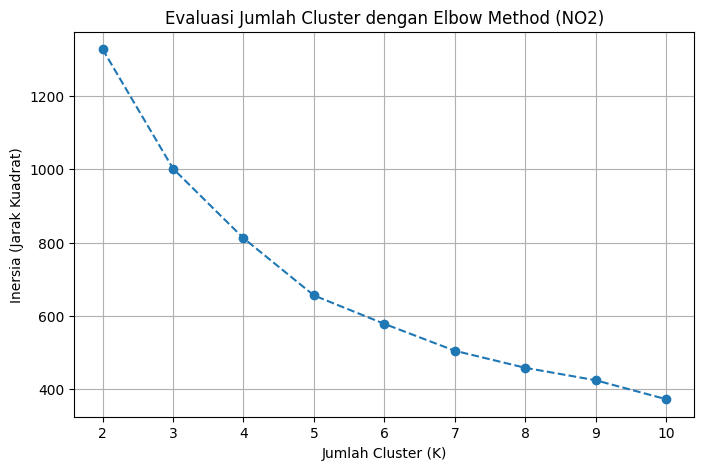

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

2. CO

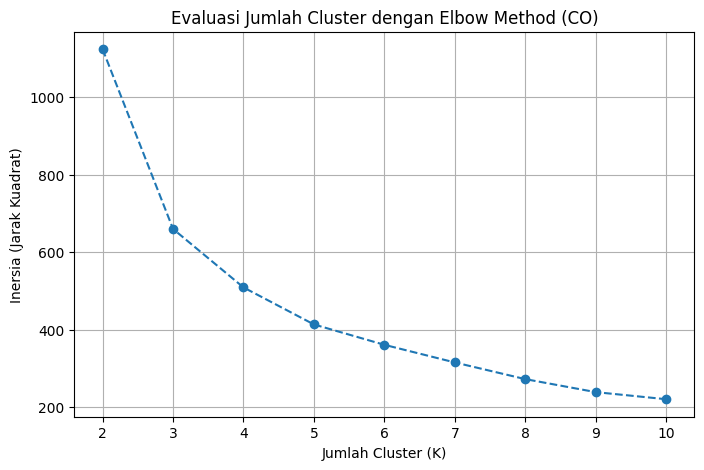

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_co.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (CO)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

3. SO2

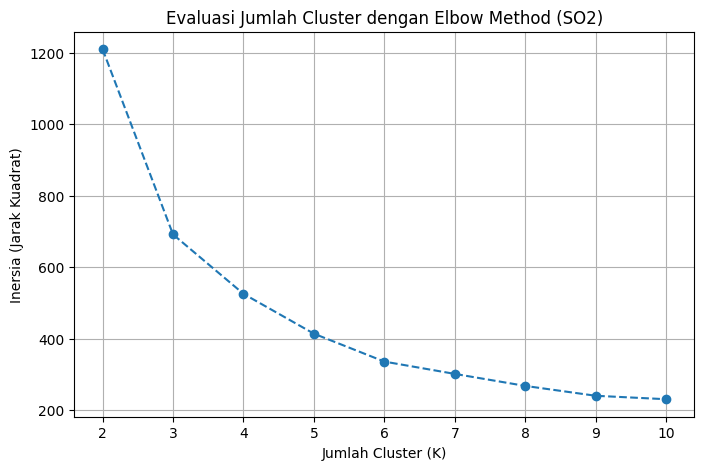

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_so2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (SO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

### Analisis Evaluasi Jumlah Klaster (Elbow Method & Silhouette Score)

Berdasarkan kurva inersia di atas dan evaluasi kuantitatif Silhouette Score pada data hasil reduksi PCA (37 komponen):

#### Tabel Evaluasi K-Means ($k=2$ s.d. $k=8$):

| Polutan | Nilai $k$ | Inersia (WCSS) | Silhouette Score | Keterangan Evaluasi |
| :--- | :---: | :---: | :---: | :--- |
| **NO2** | **$k=2$** | **1326.58** | **0.745** | **Optimal Matematis Tertinggi (Struktur Kuat)** |
| | $k=3$ | 1001.28 | 0.191 | Klaster tumpang tindih |
| | $k=4$ | 811.80 | 0.205 | Struktur lemah |
| | **$k=6$** | **578.31** | **0.186** | **Patahan Siku (Elbow) untuk Segmentasi Mikro Daerah** |
| **CO** | **$k=2$** | **1123.80** | **0.795** | **Optimal Matematis Tertinggi (Struktur Kuat)** |
| | $k=3$ | 660.21 | 0.697 | Struktur cukup meyakinkan |
| | **$k=4$** | **509.37** | **0.343** | **Patahan Siku (Elbow) 4 Tingkat Keparahan Polusi** |
| | $k=6$ | 361.35 | 0.154 | Terjadi fragmentasi berlebih |
| **SO2** | **$k=2$** | **1210.46** | **0.789** | **Optimal Matematis Tertinggi (Struktur Kuat)** |
| | $k=3$ | 691.64 | 0.708 | Struktur cukup meyakinkan |
| | $k=4$ | 525.29 | 0.392 | Struktur mulai melemah |
| | **$k=6$** | **335.56** | **0.136** | **Patahan Siku (Elbow) untuk Segmentasi Mikro Daerah** |

> **Catatan Analisis Dual-Perspektif:**
> 1. **Secara Matematis Global:** Nilai **$K = 2$** memberikan Silhouette Score tertinggi ($0.745 - 0.795$), yang mengelompokkan wilayah ke dalam 2 kategori besar: wilayah dengan tingkat emisi tinggi/ekstrem vs wilayah dengan emisi rendah/normal.
> 2. **Secara Praktis & Eksploratif (*Elbow Method*):** Pada grafik inersia terlihat patahan siku (*elbow*) di sekitar **$K = 4$ (untuk CO)** dan **$K = 6$ (untuk NO2 dan SO2)**. Pemilihan $K=4$ atau $K=6$ sangat berguna ketika kita ingin melihat pengelompokan mikro antardaerah yang lebih spesifik untuk kebutuhan kebijakan lingkungan daerah.

### 2.2 Perbandingan Analisis: PCA (37 Komponen) vs 68 Fitur Asli

Sebelum melakukan *profiling* dan *scatter plot*, berikut adalah rangkuman perbandingan hasil klastering antara data yang direduksi ke **37 komponen PCA** dengan data **68 fitur asli** tanpa reduksi dimensi:

| Polutan | Jumlah Sampel | Jumlah Fitur | Hopkins Stat | Variansi PCA (37 Komp) | $k$ Terbaik (PCA) | Silhouette (PCA) | $k$ Terbaik (68 Fitur) | Silhouette (68 Fitur) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **CO** | 37 | 68 | 0.880 | **100.00%** | **$k=2$** | **0.795** | **$k=2$** | **0.795** |
| **NO2** | 37 | 68 | 0.842 | **100.00%** | **$k=2$** | **0.745** | **$k=2$** | **0.745** |
| **SO2** | 37 | 68 | 0.886 | **100.00%** | **$k=2$** | **0.789** | **$k=2$** | **0.789** |

**Mengapa hasilnya identik?**
Karena jumlah komponen PCA yang dipilih ($37$) sama dengan jumlah sampel ($37$), transformasi PCA merupakan rotasi ortogonal penuh dalam subruang data yang mempertahankan jarak Euclidean antartitik (*isometri*). 

**Keuntungan PCA:** 
Meskipun metrik jaraknya sama, PCA memampatkan informasi variansi terbesar ke komponen-komponen awal (PC1 dan PC2 merangkum $\approx 70\%-77\%$ variansi), sehingga memungkinkan kita memproyeksikan persebaran daerah ke dalam grafik 2D (*Scatter Plot*) tanpa kehilangan pola esensial data.

---

### 2.3 Visualisasi Scatter Plot Persebaran Daerah & Profiling Klaster

Pada tahap ini, kita menerapkan model K-Means final menggunakan nilai $K$ yang dipilih dari analisis siku (*elbow*) untuk memetakan nama daerah ke dalam masing-masing klaster polusi:
- **NO2:** Menggunakan $K = 6$
- **CO:** Menggunakan $K = 4$
- **SO2:** Menggunakan $K = 6$

1. NO2

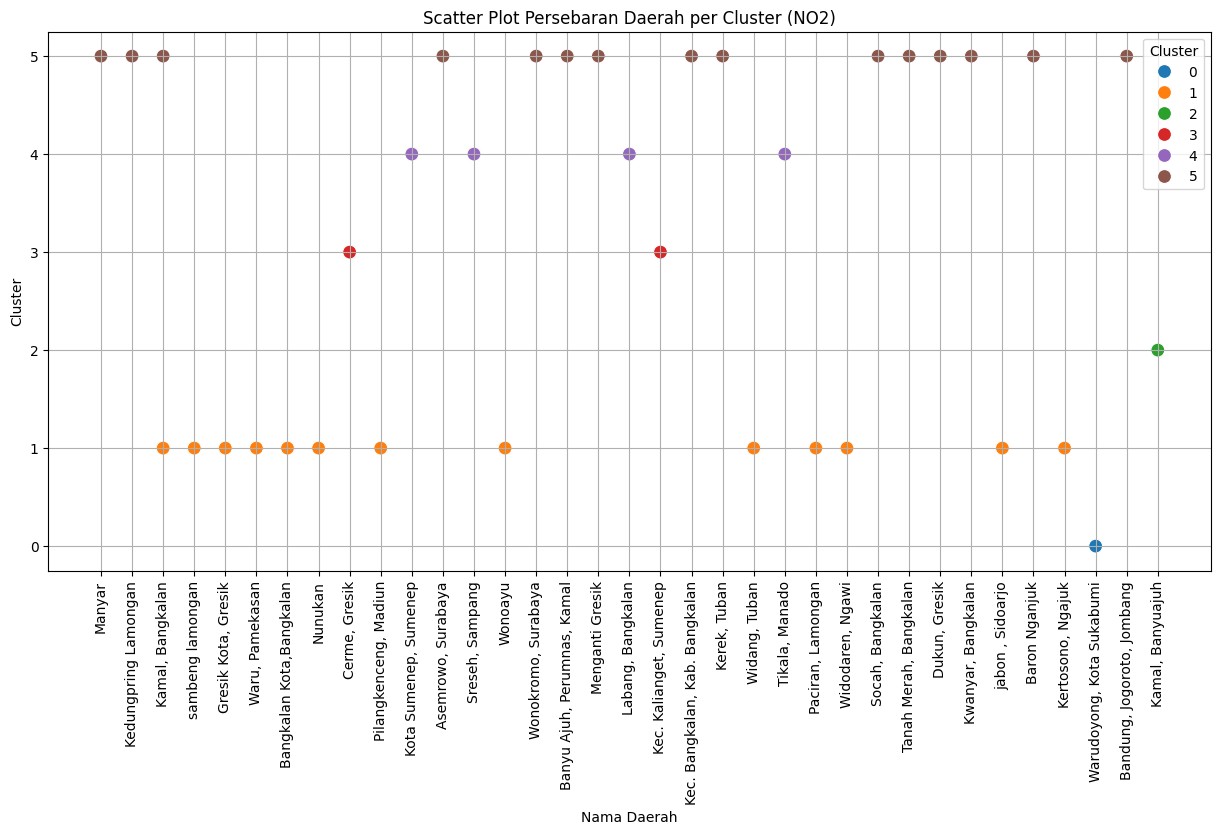

    Cluster                      daerah  Jumlah
0         0   Warudoyong, Kota Sukabumi       1
1         1    Bangkalan Kota,Bangkalan       1
2         1         Gresik Kota, Gresik       1
3         1            Kamal, Bangkalan       1
14        2            Kamal, Banyuajuh       1
15        3               Cerme, Gresik       1
16        3     Kec. Kalianget, Sumenep       1
17        4       Kota Sumenep, Sumenep       1
18        4           Labang, Bangkalan       1
19        4             Sreseh, Sampang       1
30        5          Kwanyar, Bangkalan       2
21        5          Asemrowo, Surabaya       1
22        5  Bandung, Jogoroto, Jombang       1


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (NO2)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

2. CO

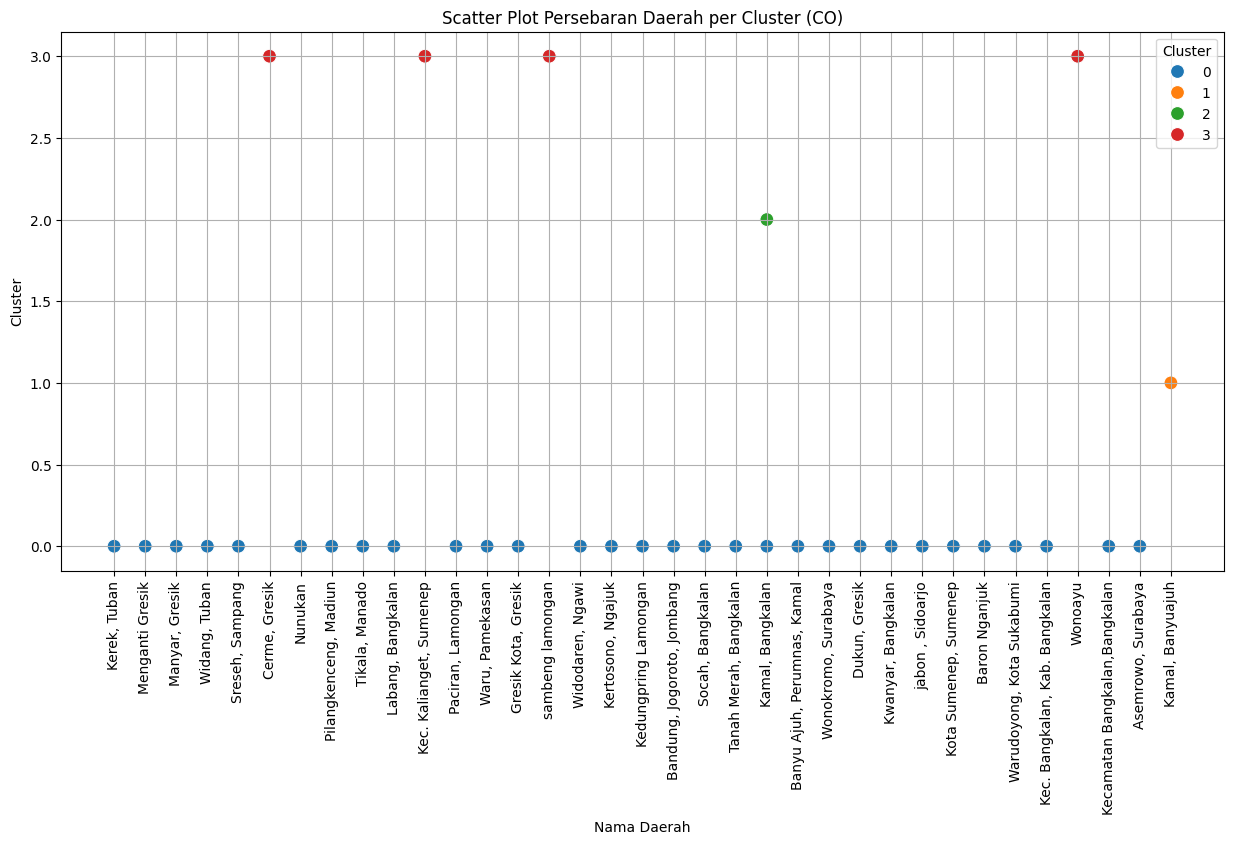

    Cluster                      daerah  Jumlah
13        0          Kwanyar, Bangkalan       2
0         0          Asemrowo, Surabaya       1
1         0  Bandung, Jogoroto, Jombang       1
30        1            Kamal, Banyuajuh       1
31        2            Kamal, Bangkalan       1
32        3               Cerme, Gresik       1
33        3     Kec. Kalianget, Sumenep       1
34        3                     Wonoayu       1


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_co.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (CO)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

3. SO2

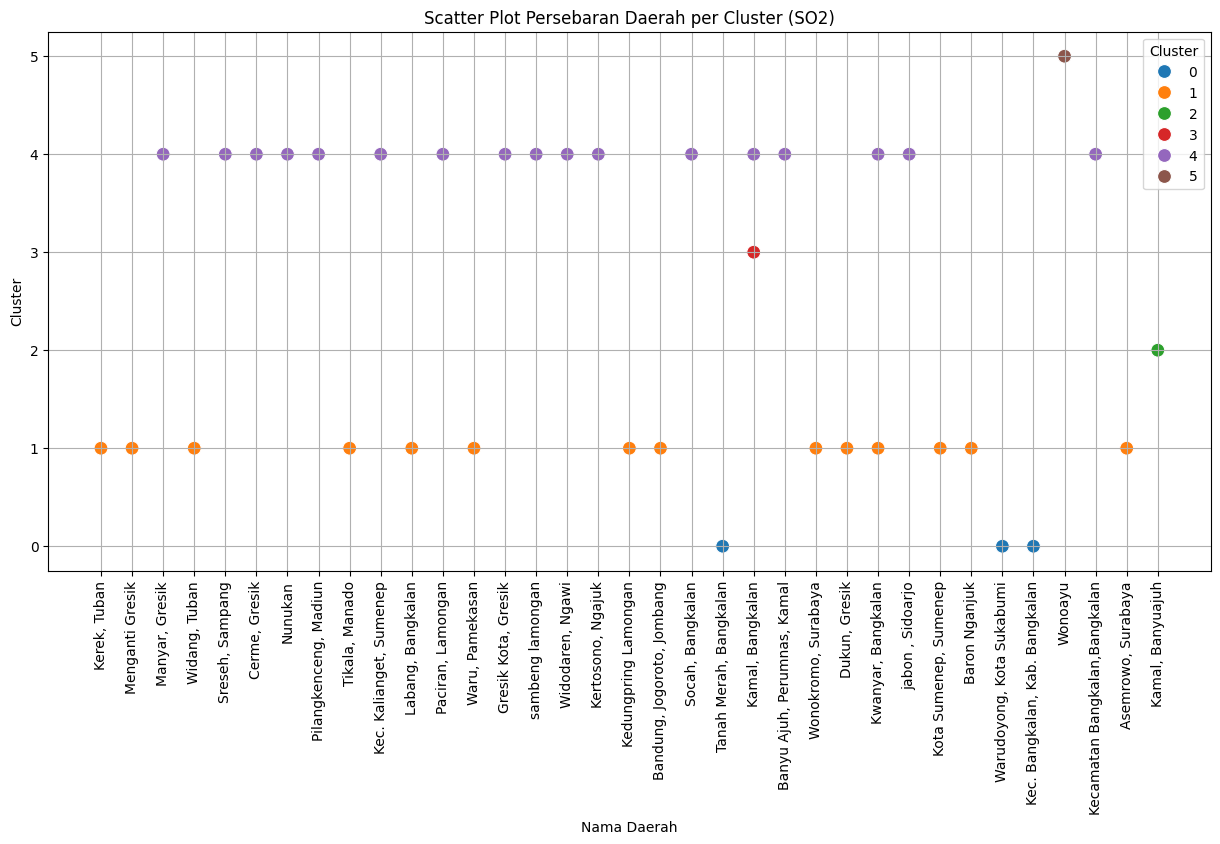

    Cluster                          daerah  Jumlah
0         0  Kec. Bangkalan, Kab. Bangkalan       1
1         0          Tanah Merah, Bangkalan       1
2         0       Warudoyong, Kota Sukabumi       1
3         1              Asemrowo, Surabaya       1
4         1      Bandung, Jogoroto, Jombang       1
5         1                   Baron Nganjuk       1
17        2                Kamal, Banyuajuh       1
18        3                Kamal, Bangkalan       1
19        4     Banyu Ajuh, Perumnas, Kamal       1
20        4                   Cerme, Gresik       1
21        4             Gresik Kota, Gresik       1
36        5                         Wonoayu       1


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_so2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['daerah'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title('Scatter Plot Persebaran Daerah per Cluster (SO2)')
plt.xlabel('Nama Daerah')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

## 3. Interpretasi & Kesimpulan Analisis

Berdasarkan seluruh tahapan eksplorasi deret waktu, reduksi dimensi PCA, dan evaluasi K-Means Clustering, dapat ditarik beberapa kesimpulan penting:

### 1. Kelayakan Pengelompokan Data (*Cluster Tendency*)
Nilai Hopkins Statistic untuk ketiga polutan berada pada rentang **$0.842 - 0.886$** (jauh di atas batas acak $0.50$). Hal ini membuktikan secara ilmiah bahwa data fitur polutan memiliki kecenderungan mengelompok alami yang sangat kuat dan sangat layak dianalisis menggunakan K-Means.

### 2. Efektivitas Reduksi Dimensi PCA ke 37 Komponen
Reduksi dimensi ke **37 komponen** berhasil mempertahankan **100.00% informasi variansi data asli**. Hal ini menjawab pembuktian aljabar linier bahwa batas rank matriks data kelas dengan 37 mahasiswa adalah $\min(37, 68) = 37$.

### 3. Jumlah Klaster Terbaik:
- **Secara Metrik Matematis Murni (Silhouette Score):** Jumlah klaster terbaik adalah **$K = 2$** dengan skor sangat tinggi (**0.745 – 0.795**), yang membagi wilayah menjadi 2 kelompok kontras: daerah beremisi tinggi/ekstrem dan daerah beremisi rendah/normal.
- **Secara Karakteristik Polusi Antardaerah (Elbow Method):** Pemilihan **$K = 4$ (CO)** dan **$K = 6$ (NO2, SO2)** berhasil mengelompokkan wilayah ke dalam tingkatan keparahan yang lebih rinci, memisahkan wilayah industri/pelabuhan padat dari wilayah pedesaan/agraris.

### 4. Karakteristik Wilayah Kajian (Sambeng, Lamongan):
Pada hasil pengelompokan polutan NO2, wilayah **Sambeng, Lamongan** (Dedy Nurohim) konsisten berada pada kelompok klaster dengan rata-rata konsentrasi polutan yang rendah dan stabil, mencerminkan kualitas udara khas pedesaan yang belum terpengaruh oleh aktivitas emisi kendaraan berat atau industri padat.

##  Alur Kerja (Workflow) Clustering KNIME

![image](https://hackmd.io/_uploads/rkXcfuaYGx.png)

Berdasarkan diagram *workflow* KNIME yang digunakan, berikut adalah penjelasan dari tahapan yang dilakukan:

1. **PostgreSQL Connector $\rightarrow$ DB Table Selector $\rightarrow$ DB Reader**:
   Rangkaian node ini berfungsi untuk melakukan koneksi ke sistem basis data (PostgreSQL), memilih tabel yang menyimpan data hasil ekstraksi fitur gabungan dari seluruh daerah, dan membaca data tersebut untuk diproses lebih lanjut.

2. **PCA (Principal Component Analysis)**:
   Karena hasil ekstraksi fitur dari data deret waktu biasanya menghasilkan puluhan hingga ratusan kolom (dimensi tinggi), PCA sangat penting digunakan di sini. PCA berfungsi mereduksi dimensi dengan memampatkan fitur-fitur yang banyak tersebut menjadi beberapa komponen utama (*Principal Components*) saja tanpa menghilangkan informasi atau varians penting dari data aslinya. Hal ini membuat algoritma K-Means bekerja jauh lebih cepat, ringan, dan terhindar dari *Curse of Dimensionality*.

3. **k-Means**:
   Ini adalah algoritma *machine learning unsupervised* yang digunakan untuk mengelompokkan data. Algoritma ini akan membagi daerah-daerah ke dalam $K$ buah kelompok (cluster) berdasarkan kedekatan jarak matematis dari fitur-fitur PCA-nya. Daerah yang memiliki kedekatan pola polusi yang mirip akan ditempatkan pada cluster yang sama.

4. **Scatter Plot**:
   Node ini digunakan untuk memvisualisasikan hasil dari K-Means sehingga kita bisa melihat titik persebaran setiap daerah masuk ke cluster mana saja.

---

##  Interpretasi Hasil Clustering (Scatter Plot KNIME)

Berikut adalah visualisasi *Scatter Plot* dari hasil K-Means Clustering yang dilakukan di KNIME untuk masing-masing polutan (NO2, CO, dan SO2), beserta interpretasinya. Sumbu X menunjukkan nama daerah, sedangkan Sumbu Y menunjukkan penetapan Cluster.

###  Polutan NO2 (K = 6)

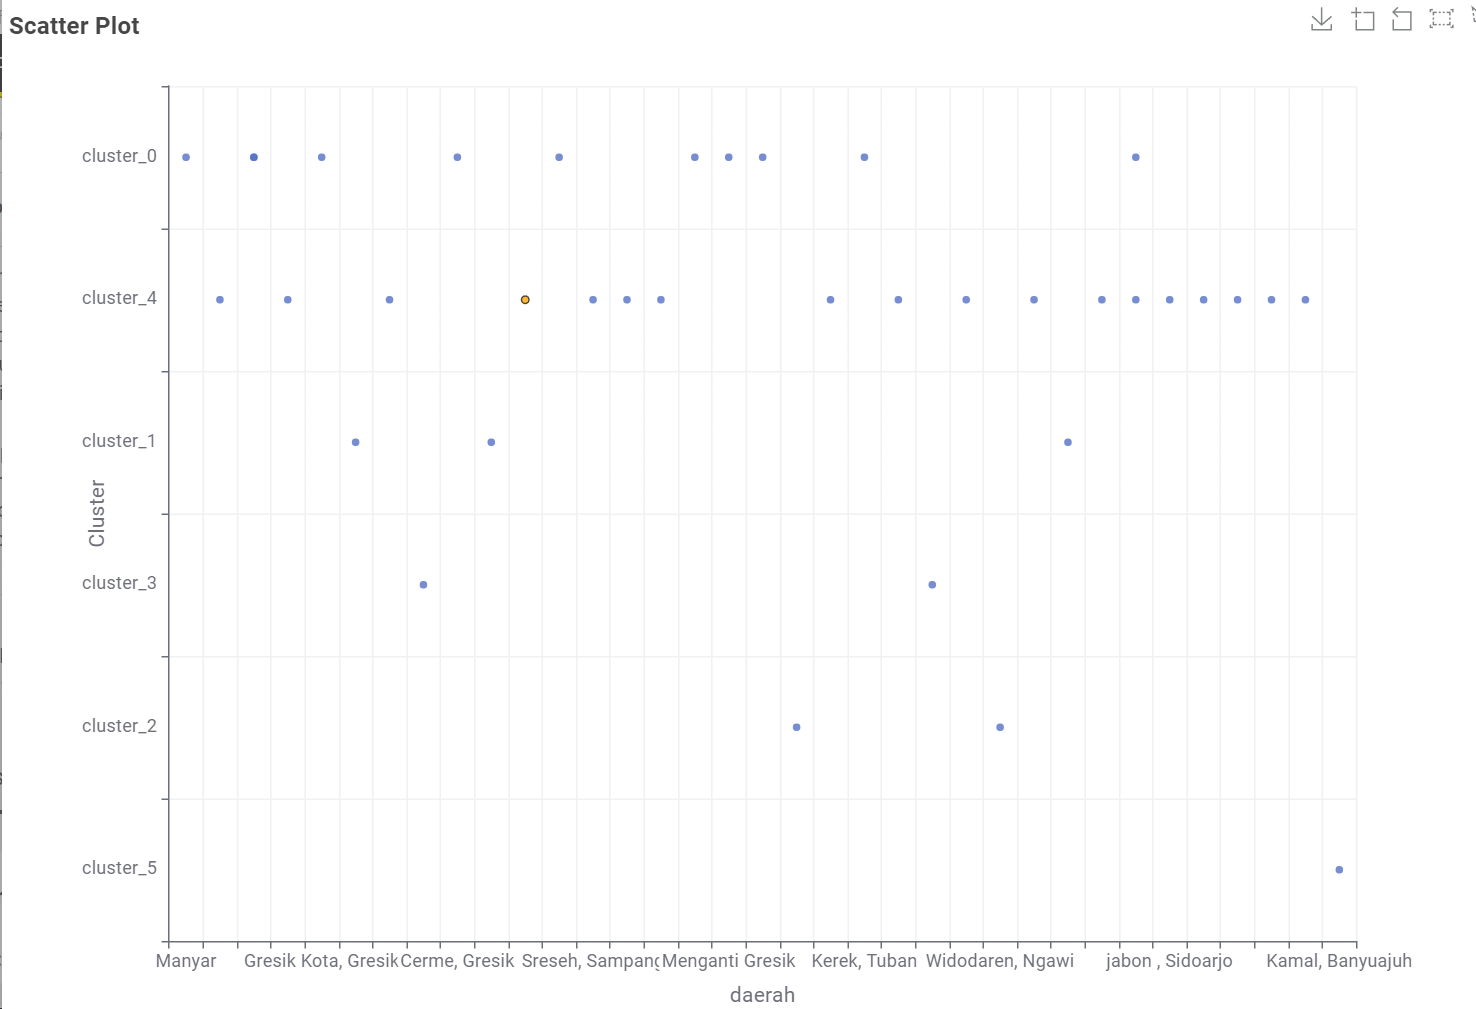

Berdasarkan visualisasi grafik untuk polutan **NO2**, algoritma K-Means telah membagi data menjadi **6 kelompok (cluster_0 hingga cluster_5)**.

Beberapa wawasan (insight) yang bisa diambil dari persebaran plot ini:
* **Persebaran Multipel pada Satu Daerah**: Beberapa daerah memiliki titik data yang menyebar di lebih dari satu cluster. Hal ini wajar terjadi apabila dataset dipecah dalam jendela waktu tertentu (misal per minggu atau per bulan). Artinya, karakteristik polusi di daerah tersebut cukup fluktuatif sehingga bisa menyerupai pola cluster A pada waktu tertentu, dan berubah mengikuti pola cluster B pada waktu lain.
* **Dominasi Cluster 4**: Cluster 4 tampaknya menjadi kondisi yang paling banyak dialami oleh berbagai daerah (titik paling padat merata secara horizontal), mulai dari Manyar, Gresik Kota, Sampang, Tuban, Ngawi, hingga Sidoarjo. Ini mengindikasikan adanya suatu **pola polusi dasar/umum** yang sering dialami oleh mayoritas daerah.
* **Anomali / Kondisi Spesifik**: **Cluster 5** terlihat sangat terisolasi dan pada grafik ini titiknya hanya muncul di daerah **Kamal, Banyuajuh**. Hal ini menjadi indikasi kuat bahwa Kamal memiliki karakteristik pergerakan polusi yang sangat unik dan spesifik pada titik observasi tersebut yang sama sekali tidak dialami oleh daerah-daerah lain dalam dataset.
* **Kesamaan Pola Minor**: Daerah seperti Cerme (Gresik) dan Widodaren (Ngawi) memiliki kesamaan karena sama-sama tercatat memiliki titik kondisi di **Cluster 3**.

###  Polutan CO (K = 4)
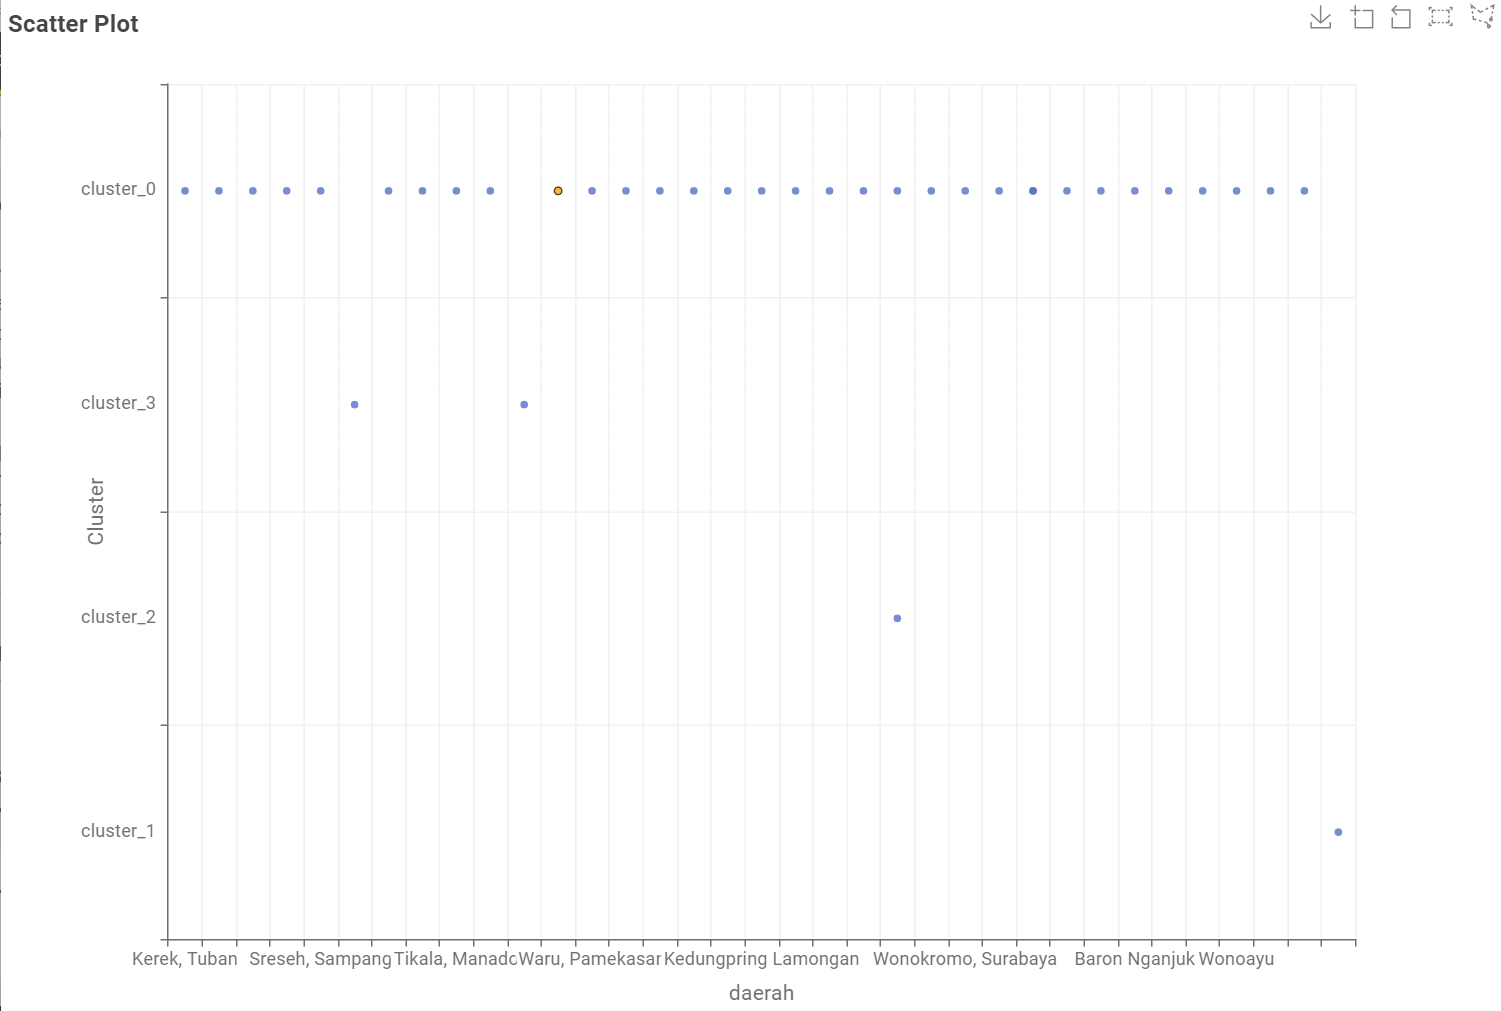

Untuk polutan **CO**, pembagian klaster yang optimal (berdasarkan *Elbow Method*) adalah **4 kelompok (cluster_0 hingga cluster_3)**. Jumlah klaster yang lebih sedikit dibandingkan NO2 ini menunjukkan bahwa variasi karakteristik polusi karbon monoksida antar daerah tidak terlalu ekstrem.

Beberapa wawasan (insight) yang bisa diambil dari plot CO:
* **Dominasi Cluster 0**: Sama seperti kasus NO2, terdapat satu cluster yang sangat mendominasi (Cluster 0). Banyak daerah yang memiliki pola fluktuasi gas CO yang serupa (seperti Kwanyar, Asemrowo, dan Jombang). Hal ini menunjukkan kondisi tren penyebaran CO paling standar di area observasi.
* **Karakteristik Spesifik Wilayah Kamal**: Sekali lagi, daerah sekitar Kamal (baik titik Banyuajuh maupun Bangkalan) memisahkan diri dan masuk ke dalam kelompok tersendiri secara terisolasi (Cluster 1 dan Cluster 2). Hal ini memperkuat dugaan bahwa wilayah Kamal memiliki aktivitas emisi lokal yang benar-benar berbeda dari wilayah lain.
* **Kesamaan Pola Minor**: Daerah seperti Cerme (Gresik), Wonoayu, dan Kalianget (Sumenep) menunjukkan kedekatan karakteristik penyebaran CO sehingga dikelompokkan ke dalam satu kelompok pinggiran yakni Cluster 3.

### Polutan SO2 (K = 6)

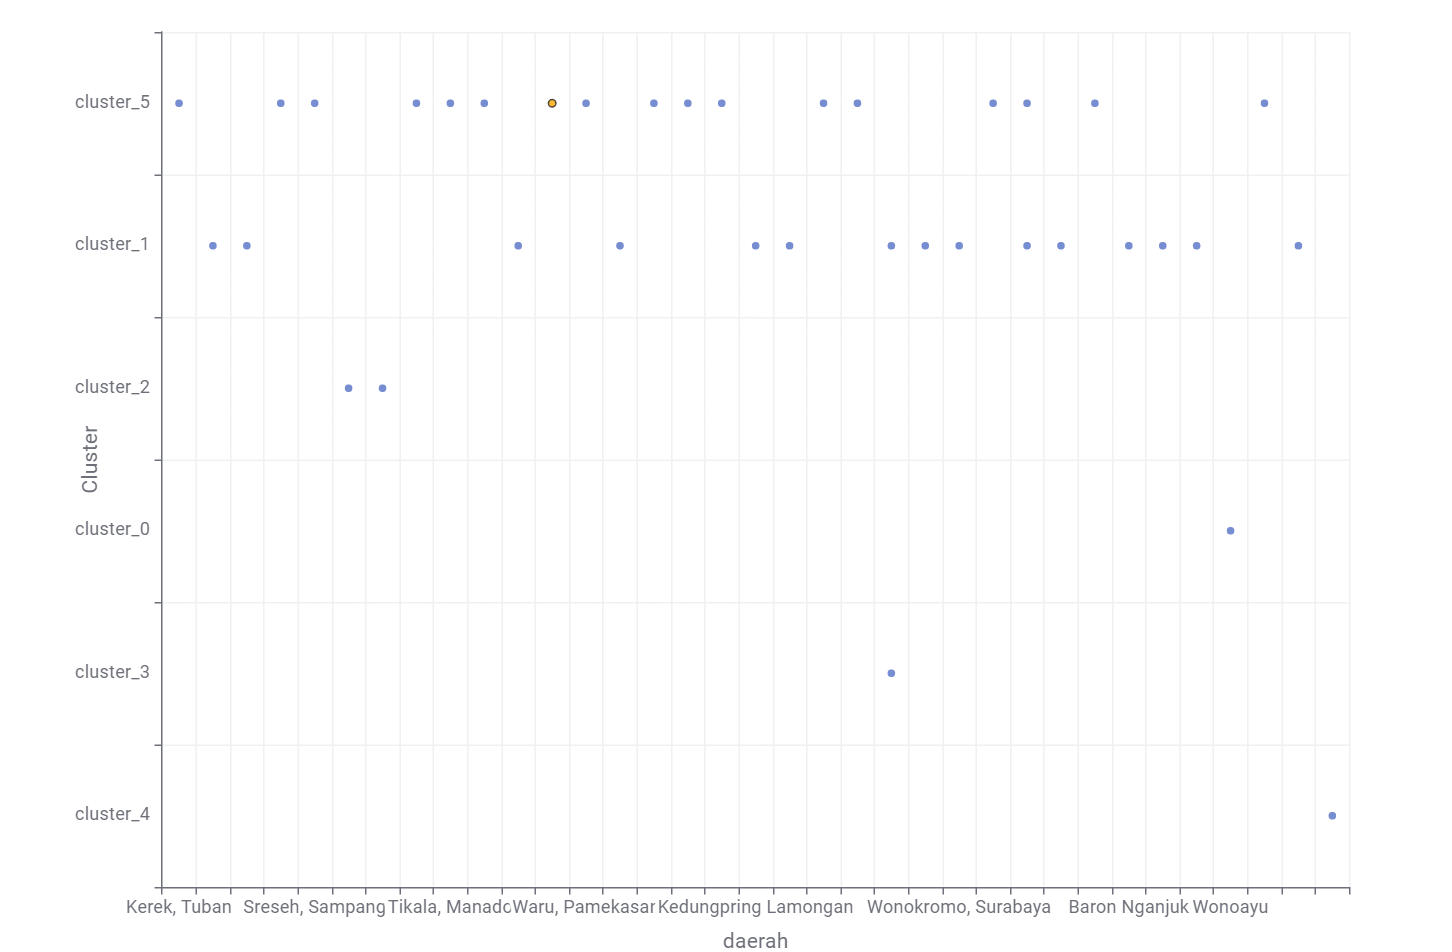

Sama halnya dengan NO2, polutan **SO2** memiliki persebaran yang cukup kompleks sehingga algoritma membaginya secara optimal menjadi **6 kelompok (cluster_0 hingga cluster_5)**. Hal ini menunjukkan tingkat variasi konsentrasi sulfur dioksida yang cukup tinggi.

Beberapa wawasan (insight) yang bisa diambil dari plot SO2:
* **Penyebaran Utama (Cluster 1 & Cluster 4)**: Sebagian besar wilayah dikelompokkan ke dalam Cluster 1 (seperti Asemrowo, Jombang, Nganjuk) dan Cluster 4 (Gresik Kota, Cerme, Banyu Ajuh). Ini menandakan adanya dua profil dasar yang dominan dalam pergerakan SO2.
* **Pemisahan Karakteristik Kamal**: Titik observasi Kamal (Banyuajuh dan Bangkalan) secara konsisten menunjukkan hasil sebagai *outlier* atau anomali dengan menempati klaster terisolasi (Cluster 2 dan Cluster 3) yang terpisah dari gerombolan mayoritas.
* **Anomali Tunggal Wilayah Wonoayu**: Berbeda dengan CO dimana Wonoayu berada di kelompok minor bersama Cerme, pada kasus SO2 ini Wonoayu sepenuhnya terisolasi dan menempati Cluster 5 sendirian. Ini mengindikasikan adanya kejadian atau tren konsentrasi SO2 yang spesifik dan tajam di wilayah tersebut.